In [145]:
import pandas as pd

combined_df = pd.read_csv("combined_data.csv")
combined_df["date"] = pd.to_datetime(combined_df["date"])


In [146]:
combined_df.head()

,geography,stratum,date,organism,resistance_pct,series_id,model_region,prescribing_rate,month,sin_month,...,lag_12,presc_lag_1,presc_lag_3,presc_lag_6,trend,prescribing_x_month,roll_mean_3,roll_mean_6,roll_std_6,presc_roll_mean_3
0,East Midlands,Amikacin,2021-10-01,E-coli,1.52,E-coli__Amikacin__East Midlands,Midlands,1.34,10,-8.660254e-01,...,0.53,1.31,1.28,1.25,0.21,13.40,1.853333,1.788333,0.191668,1.296667
1,East Midlands,Amikacin,2021-11-01,E-coli,1.17,E-coli__Amikacin__East Midlands,Midlands,1.37,11,-5.000000e-01,...,0.92,1.34,1.30,1.25,-0.55,15.07,1.813333,1.776667,0.207621,1.316667
2,East Midlands,Amikacin,2021-12-01,E-coli,0.72,E-coli__Amikacin__East Midlands,Midlands,1.41,12,-2.449294e-16,...,0.93,1.37,1.31,1.26,-0.68,16.92,1.513333,1.696667,0.325310,1.340000
3,East Midlands,Amikacin,2022-01-01,E-coli,1.90,E-coli__Amikacin__East Midlands,Midlands,1.41,1,5.000000e-01,...,0.53,1.41,1.34,1.28,-0.80,1.41,1.136667,1.495000,0.486734,1.373333
4,East Midlands,Amikacin,2022-02-01,E-coli,2.43,E-coli__Amikacin__East Midlands,Midlands,1.43,2,8.660254e-01,...,0.17,1.41,1.37,1.30,0.73,2.86,1.263333,1.538333,0.513085,1.396667


In [147]:
combined_df.groupby(["series_id", "date"]).size().sort_values(ascending=False).head(20)

series_id                                            date      
E-coli__Third Generation Cephalosporins__South East  2022-04-01    4
                                                     2022-05-01    4
                                                     2022-06-01    4
                                                     2022-07-01    4
                                                     2022-08-01    4
                                                     2022-09-01    4
                                                     2022-10-01    4
                                                     2022-11-01    4
                                                     2022-12-01    4
                                                     2023-01-01    4
                                                     2023-02-01    4
                                                     2023-03-01    4
                                                     2023-04-01    4
                                       

In [148]:
combined_df.shape

(13578, 32)

In [60]:
window_length = 12 
train_cutoff = "2024-03-01"

In [61]:
combined_df.columns

Index(['geography', 'stratum', 'date', 'organism', 'resistance_pct',
       'series_id', 'model_region', 'prescribing_rate', 'month', 'sin_month',
       'cos_month', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6',
       'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'presc_lag_1',
       'presc_lag_3', 'presc_lag_6', 'trend', 'prescribing_x_month',
       'roll_mean_3', 'roll_mean_6', 'roll_std_6', 'presc_roll_mean_3'],
      dtype='object')

In [62]:
feature_cols = (
    [f'lag_{i}' for i in range (1, window_length +1)]
     + [f'presc_lag_{i}'for i in [1,3, 6]]
     + ["sin_month", "cos_month", "trend",
        "prescribing_x_month", "roll_mean_3", "roll_mean_6",
          "roll_std_6", "presc_roll_mean_3"]
     
)




In [63]:
combined_df.shape

(13578, 32)

In [64]:
def create_direct_targets(df, horizon=6):
    dfs = []
    for sid, g in df.groupby("series_id"):
        g = g.sort_index()
        for h in range(1, horizon+1):
            g[f"target_h{h}"] = g["resistance_pct"].shift(-h)
        dfs.append(g)
    out = pd.concat(dfs).sort_index()
    return out.dropna()

combined_df = create_direct_targets(combined_df, horizon=6)


In [65]:
combined_df = combined_df.dropna().reset_index(drop=True)


In [66]:
combined_df["date"] = pd.to_datetime(combined_df["date"])


In [67]:
def time_split_per_series(df, cutoff):
     train = df[df["date"] < cutoff].copy() 
     test = df[df["date"] >= cutoff].copy()
     return train, test

# %%
train_df, test_df = time_split_per_series(combined_df, train_cutoff)

# %%
print(f"\nTrain: {len(train_df)} rows")
print(f"\nTest: {len(test_df)} rows")


Train: 9162 rows

Test: 3174 rows


In [68]:
# %%
X_train = train_df[feature_cols]
y_train = train_df['resistance_pct']

# %%
X_test = test_df[feature_cols]
y_test = test_df['resistance_pct']

# %%
print(f"\nFeatures used ({len(feature_cols)}): {feature_cols[:3]}...{feature_cols[-2:]}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



Features used (23): ['lag_1', 'lag_2', 'lag_3']...['roll_std_6', 'presc_roll_mean_3']
X_train shape: (9162, 23)
X_test shape: (3174, 23)
y_train shape: (9162,)
y_test shape: (3174,)


In [69]:
combined_df.columns

Index(['geography', 'stratum', 'date', 'organism', 'resistance_pct',
       'series_id', 'model_region', 'prescribing_rate', 'month', 'sin_month',
       'cos_month', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6',
       'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'presc_lag_1',
       'presc_lag_3', 'presc_lag_6', 'trend', 'prescribing_x_month',
       'roll_mean_3', 'roll_mean_6', 'roll_std_6', 'presc_roll_mean_3',
       'target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5',
       'target_h6'],
      dtype='object')

In [70]:
combined_df.shape

(12336, 38)

In [71]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sktime.forecasting.compose import make_reduction
from sktime.forecasting.base import ForecastingHorizon
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor


In [72]:
lr_forecaster = LinearRegression()

# %%
lgbm_forecaster =  LGBMRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        num_leaves=31, #default
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        random_state=42, 
        verbose=-1
    )


# %%
xgb_forecaster = XGBRegressor(
        n_estimators = 300,
        max_depth=5,
        learning_rate = 0.05,
        subsample=0.8,
        colsample_bytree =0.8,
        random_state = 42,
        eval_metric = "rmse"
    )

# %%
rf_forecaster = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )


In [73]:
models = {
    "LinearRegression": lr_forecaster,
    "LightGBM": lgbm_forecaster,
    "XGBoost": xgb_forecaster,
    "RandomForest": rf_forecaster
}

In [74]:
models_direct = {}

for model_name, base_model in models.items():
    print(f"\n=== Training {model_name} (Direct Forecasting) ===")

    models_direct[model_name] = {}

    for h in range(1, 7):
        print(f"  Training horizon {h} model...")

        y_train_h = train_df[f"target_h{h}"]

        model = base_model.__class__(**base_model.get_params())
        model.fit(X_train, y_train_h)

        models_direct[model_name][h] = model

    print(f"  All 6 horizon models trained for {model_name}.")




=== Training LinearRegression (Direct Forecasting) ===
  Training horizon 1 model...
  Training horizon 2 model...
  Training horizon 3 model...
  Training horizon 4 model...
  Training horizon 5 model...
  Training horizon 6 model...
  All 6 horizon models trained for LinearRegression.

=== Training LightGBM (Direct Forecasting) ===
  Training horizon 1 model...
  Training horizon 2 model...
  Training horizon 3 model...
  Training horizon 4 model...
  Training horizon 5 model...
  Training horizon 6 model...
  All 6 horizon models trained for LightGBM.

=== Training XGBoost (Direct Forecasting) ===
  Training horizon 1 model...
  Training horizon 2 model...
  Training horizon 3 model...
  Training horizon 4 model...
  Training horizon 5 model...
  Training horizon 6 model...
  All 6 horizon models trained for XGBoost.

=== Training RandomForest (Direct Forecasting) ===
  Training horizon 1 model...
  Training horizon 2 model...
  Training horizon 3 model...
  Training horizon 4 mode

In [75]:
results_direct = {}

for model_name in models_direct.keys():
    print(f"\n=== Evaluating {model_name} on TEST SET ===")

    horizon_mae = {}

    for h in range(1, 7):
        y_test_h = test_df[f"target_h{h}"]
        y_pred_h = models_direct[model_name][h].predict(X_test)

        mae_h = mean_absolute_error(y_test_h, y_pred_h)
        horizon_mae[f"H{h}"] = mae_h

        print(f"  Horizon {h} MAE: {mae_h:.4f}")

    results_direct[model_name] = horizon_mae



=== Evaluating LinearRegression on TEST SET ===
  Horizon 1 MAE: 1.2577
  Horizon 2 MAE: 1.5387
  Horizon 3 MAE: 1.5997
  Horizon 4 MAE: 1.6383
  Horizon 5 MAE: 1.6884
  Horizon 6 MAE: 1.7368

=== Evaluating LightGBM on TEST SET ===
  Horizon 1 MAE: 1.2961
  Horizon 2 MAE: 1.5584
  Horizon 3 MAE: 1.6414
  Horizon 4 MAE: 1.6835
  Horizon 5 MAE: 1.7433
  Horizon 6 MAE: 1.7850

=== Evaluating XGBoost on TEST SET ===
  Horizon 1 MAE: 1.2874
  Horizon 2 MAE: 1.5594
  Horizon 3 MAE: 1.6465
  Horizon 4 MAE: 1.6764
  Horizon 5 MAE: 1.7498
  Horizon 6 MAE: 1.7692

=== Evaluating RandomForest on TEST SET ===
  Horizon 1 MAE: 1.2926
  Horizon 2 MAE: 1.5064
  Horizon 3 MAE: 1.5720
  Horizon 4 MAE: 1.6197
  Horizon 5 MAE: 1.6685
  Horizon 6 MAE: 1.7160


In [84]:
models_direct["XGBoost"][h]


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [151]:
test_pred_df = []

for h in range(1, 7):
    y_test_h = test_df[f"target_h{h}"]
    y_pred_h = models_direct["XGBoost"][h].predict(X_test)

    temp = pd.DataFrame({
        "series_id": test_df["series_id"].values,
        "date": test_df["date"],
        "horizon": h,
        "actual": y_test_h,
        "pred": y_pred_h
    })

    test_pred_df.append(temp)

df_ml_direct_test_pred = pd.concat(test_pred_df, ignore_index=True)
df_ml_direct_test_pred

,series_id,date,horizon,actual,pred
0,E-coli__Amikacin__East Midlands,2024-03-01,1,4.35,2.776246
1,E-coli__Amikacin__East Midlands,2024-04-01,1,3.38,2.971287
2,E-coli__Amikacin__East Midlands,2024-05-01,1,4.17,4.047620
3,E-coli__Amikacin__East Midlands,2024-06-01,1,3.54,2.998221
4,E-coli__Amikacin__East Midlands,2024-07-01,1,2.94,3.609045
...,...,...,...,...,...
19039,e-faecium__Glycopeptides__Yorkshire and Humber,2024-08-01,6,14.85,20.145290
19040,e-faecium__Glycopeptides__Yorkshire and Humber,2024-09-01,6,20.45,20.688805
19041,e-faecium__Glycopeptides__Yorkshire and Humber,2024-10-01,6,21.74,18.567928
19042,e-faecium__Glycopeptides__Yorkshire and Humber,2024-11-01,6,25.47,18.919958


In [154]:
def clean_predictions(df, series_id, horizon):

    # 1. Filter the series
    series_df = df[df["series_id"] == series_id].copy()

    # 2. Filter the horizon
    h_df = series_df[series_df["horizon"] == horizon].copy()

    # 3. Deduplicate by keeping the most recent forecast origin
    h_clean = (
        h_df.sort_values("date")
            .drop_duplicates(subset="date", keep="last")
            .sort_values("date")
            .reset_index(drop=True)
    )

    # 4. Return only the clean columns
    return h_clean[["date", "actual", "pred"]]


In [155]:
clean_h6 = clean_predictions(
    df_ml_direct_test_pred,
    series_id="E-coli__Amikacin__South East",
    horizon=6
)

clean_h6.head()

,date,actual,pred
0,2024-03-01,3.30,2.361671
1,2024-04-01,2.63,2.516623
2,2024-05-01,2.85,2.780025
3,2024-06-01,2.85,3.004353
4,2024-07-01,3.08,2.736604


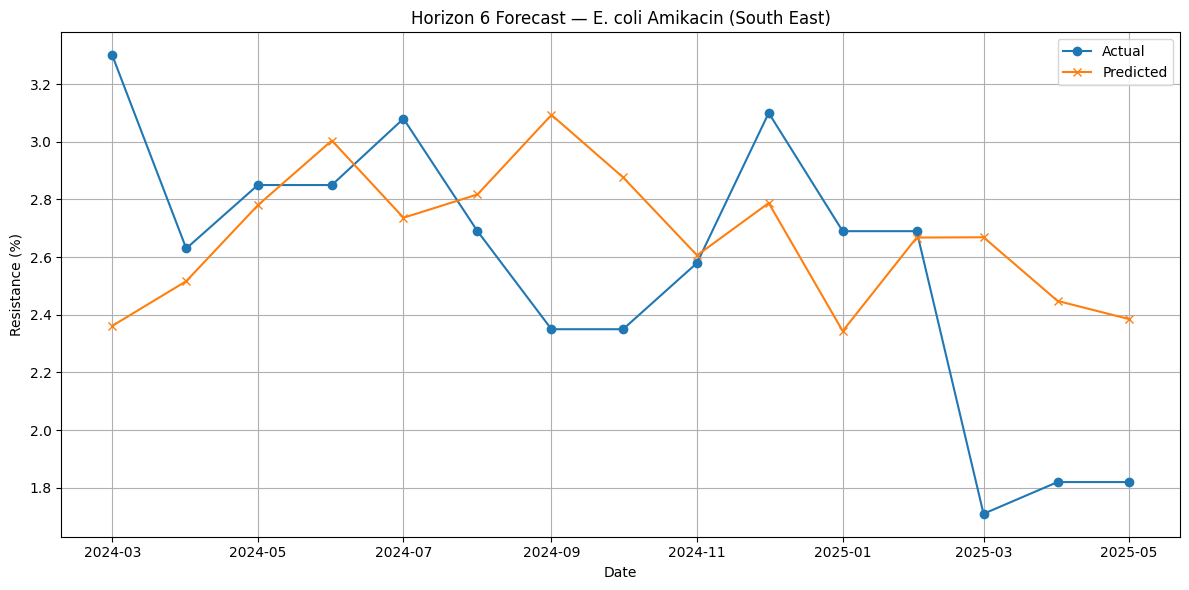

In [156]:
plt.figure(figsize=(12,6))
plt.plot(clean_h6["date"], clean_h6["actual"], marker="o", label="Actual")
plt.plot(clean_h6["date"], clean_h6["pred"], marker="x", label="Predicted")
plt.title("Horizon 6 Forecast — E. coli Amikacin (South East)")
plt.xlabel("Date")
plt.ylabel("Resistance (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Forecasting

Backtesting/cross validation

In [76]:
def rolling_backtest_direct_ml(df, feature_cols, horizon=6, min_history=24, step=1, model_builder=None):

    preds = []
    actuals = []
    dates = []

    all_dates = sorted(df["date"].unique())

    for i in range(min_history, len(all_dates) - horizon, step):

        train_end = all_dates[i]
        test_start = all_dates[i + 1]
        test_end   = all_dates[i + horizon]

        train = df[df["date"] <= train_end]
        test  = df[(df["date"] > train_end) & (df["date"] <= test_end)]

        if len(train) < min_history or len(test) < horizon:
            continue

        # Train 6 direct models
        models_h = {}
        for h in range(1, horizon+1):
            m = model_builder()
            X_train = train[feature_cols]
            y_train = train[f"target_h{h}"]
            m.fit(X_train, y_train)
            models_h[h] = m

        # Predict 6 horizons
        X_test = test[feature_cols].iloc[:horizon]
        y_pred_h = []
        for h in range(1, horizon+1):
            y_pred_h.append(models_h[h].predict(X_test.iloc[[h-1]])[0])

        # True values
        y_true_h = test["resistance_pct"].values[:horizon]

        preds.append(y_pred_h)
        actuals.append(y_true_h)
        dates.append(test["date"].values[:horizon])

    return (
        np.array(preds),
        np.array(actuals),
        np.array(dates)
    )




In [77]:
import numpy as np

In [78]:
def build_xgb():
    return XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="rmse"
    )

y_pred_dir, y_true_dir, dates_dir = rolling_backtest_direct_ml(
    combined_df,
    feature_cols,
    horizon=6,
    min_history=24,
    step=1,
    model_builder=build_xgb
)


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("ML‑Direct MAE:", mean_absolute_error(y_true_dir.flatten(), y_pred_dir.flatten()))
print("ML‑Direct RMSE:", np.sqrt(mean_squared_error(y_true_dir.flatten(), y_pred_dir.flatten())))



ML‑Direct MAE: 0.6454961220423381
ML‑Direct RMSE: 0.8094637741874746


In [80]:
for h in range(6):
    print(f"H{h+1} MAE:", mean_absolute_error(y_true_dir[:,h], y_pred_dir[:,h]))


H1 MAE: 0.6254452835083008
H2 MAE: 0.5994783992767334
H3 MAE: 0.5752264129638671
H4 MAE: 0.6377461204528808
H5 MAE: 0.7001547760009765
H6 MAE: 0.7349257400512694


In [82]:


def build_ml_direct_df(y_true, y_pred, dates):
    rows = []
    n_windows = y_true.shape[0]

    for i in range(n_windows):
        for h in range(6):
            rows.append({
                "date": pd.to_datetime(dates[i][h]),
                "horizon": h+1,
                "actual": y_true[i, h],
                "pred": y_pred[i, h]
            })

    return pd.DataFrame(rows)

df_ml_direct_actual_pred = build_ml_direct_df(y_true_dir, y_pred_dir, dates_dir)
df_ml_direct_actual_pred.head()

,date,horizon,actual,pred
0,2022-12-01,1,2.72,2.133733
1,2023-01-01,2,2.72,2.731219
2,2023-02-01,3,2.33,2.159500
3,2023-03-01,4,1.23,2.558163
4,2023-04-01,5,1.75,2.006624


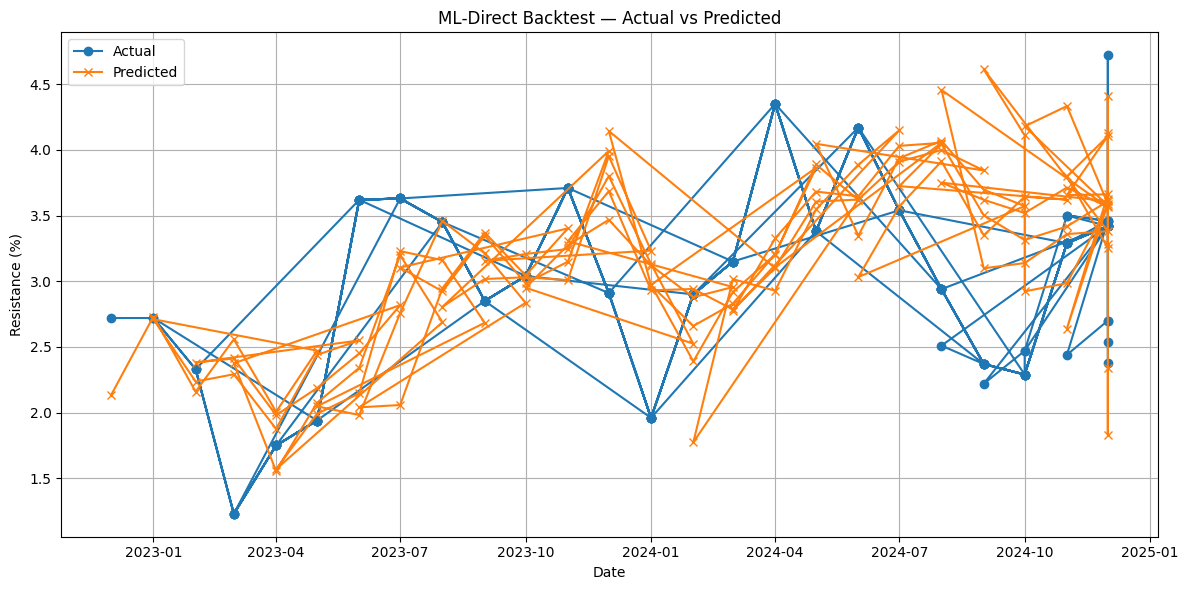

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_ml_direct_actual_pred["date"], 
         df_ml_direct_actual_pred["actual"], 
         label="Actual", marker="o")

plt.plot(df_ml_direct_actual_pred["date"], 
         df_ml_direct_actual_pred["pred"], 
         label="Predicted", marker="x")

plt.title("ML‑Direct Backtest — Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Resistance (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [293]:
def forecast_direct(models_direct, df, feature_cols, horizon=6, window_length=12):

    forecasts = []
    df = df.sort_values(["series_id", "date"]).copy()

    last_windows = (
        df.groupby("series_id", group_keys=False)
        .tail(window_length)
        .copy()
    )

    for sid, window in last_windows.groupby("series_id"):

        X_last = window[feature_cols].iloc[-1:]

        preds = []
        last_date = window["date"].max()

        for h in range(1, horizon+1):
            y_hat = models_direct["XGBoost"][h].predict(X_last)[0]
            forecast_date = last_date + pd.DateOffset(months=h)
            preds.append((forecast_date, y_hat))

        series_forecast = pd.DataFrame({
            "series_id": sid,
            "date": [p[0] for p in preds],
            "forecast": [p[1] for p in preds]
        })

        forecasts.append(series_forecast)

    forecast_df = pd.concat(forecasts, ignore_index=True)

    forecast_df[["organism","antibiotic","region"]] = (
        forecast_df["series_id"].str.split("__", expand=True)
    )

    return forecast_df[["organism","antibiotic","region","date","forecast","series_id"]]


In [294]:
future_fcst = forecast_direct(models_direct, combined_df, feature_cols)


In [295]:
future_fcst.head()

,organism,antibiotic,region,date,forecast,series_id
0,E-coli,Amikacin,East Midlands,2025-01-01,3.299828,E-coli__Amikacin__East Midlands
1,E-coli,Amikacin,East Midlands,2025-02-01,3.354658,E-coli__Amikacin__East Midlands
2,E-coli,Amikacin,East Midlands,2025-03-01,3.324180,E-coli__Amikacin__East Midlands
3,E-coli,Amikacin,East Midlands,2025-04-01,3.309012,E-coli__Amikacin__East Midlands
4,E-coli,Amikacin,East Midlands,2025-05-01,3.451891,E-coli__Amikacin__East Midlands
